# 02 v2 — Feature engineering corregido — OULAD

**Objetivo específico 2** (CRISP-DM: preparación de los datos). Actividades A2.1 a A2.7.

Corrige la versión 1 con las decisiones derivadas del análisis estadístico
(`03_analisis_estadistico.ipynb`, §8) y con los hallazgos de la revisión metodológica.

**Correcciones respecto de la v1**

| # | Corrección | Evidencia |
|---|---|---|
| 1 | `variacion_actividad` → `log_ratio_actividad = log((q₂+1)/(q₁+1))` | asimetría 16,9 → 0,06; curtosis 476,4 → 1,43; sin indefiniciones |
| 2 | Se suprimen `frecuencia_acceso` (≡ `dias_activos`/28, ρ = 1,000) y `score_min_temprano` (ρ = 0,986) | §6.3 del informe estadístico |
| 3 | Filtro explícito `assessment_type != 'Exam'` en el desempeño temprano | la exclusión ya no depende solo de la fecha |
| 4 | Indicador `sin_entregas_tempranas` (V de Cramér = 0,327 con el abandono) | §5.2 del informe estadístico |
| 5 | Variable `momento_retiro` (4 categorías) — **no es predictora** | 26,59 % de los abandonos son previos al día 0 |
| 6 | Imputación centinela solo donde el cero es semánticamente exacto | §5.3 del informe estadístico |
| 7 | Se suprime `semanas_inactivas` (≡ 4 − `semanas_activas`, ρ = −1,000) | redundancia exacta no detectada en la v1 |
| 8 | `coef_variacion_clics` se calcula sobre los 28 días de la ventana, no solo sobre los días activos | la CV entre días activos no puede capturar la irregularidad producida por la inactividad |
| 9 | Se conserva `n_interacciones_pre_curso` junto al indicador binario | la binarización descartaba una señal ya construida |

**Columnas suprimidas respecto de la v1 (seis, no dos):** `frecuencia_acceso`,
`score_min_temprano`, `semanas_inactivas`, `std_clics_diarios`, `media_clics_diarios`
y `ultimo_dia_interaccion_temprana` (las tres últimas eran intermedias de cálculo).

**Producto:** `dataset_analitico_oulad_v2.parquet`.

In [1]:
import sys, pandas as pd, numpy as np
from pathlib import Path
from scipy import stats as st

pd.set_option('display.max_columns', None)
RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed'); PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

VENTANA = 28                 # dias de la ventana temprana (dias 0..27)
KEY = ['id_student', 'code_module', 'code_presentation']   # unidad de analisis: la inscripcion

# Trazabilidad del entorno (reproducibilidad)
import scipy, matplotlib
print('python', sys.version.split()[0], '| pandas', pd.__version__,
      '| numpy', np.__version__, '| scipy', scipy.__version__,
      '| matplotlib', matplotlib.__version__)

python 3.11.9 | pandas 2.2.2 | numpy 1.26.4 | scipy 1.17.1 | matplotlib 3.9.0


In [2]:
import matplotlib.pyplot as plt

# Estilo grafico del proyecto (Knaflic): gris claro para el contexto, un unico color
# de acento y color de riesgo reservado al abandono, con etiquetado directo.
GRIS, GRISOS, TINTA = '#D4D4D4', '#9B9B9B', '#404040'
ACENTO, RIESGO = '#0073B1', '#E8833A'
plt.rcParams.update({'font.family':'sans-serif','font.size':9,'text.color':TINTA,
    'axes.edgecolor':GRISOS,'axes.labelcolor':TINTA,'axes.titlecolor':TINTA,
    'xtick.color':GRISOS,'ytick.color':GRISOS,'xtick.labelcolor':TINTA,'ytick.labelcolor':TINTA,
    'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})

def limpiar(ax, y_grid=True):
    ax.spines['left'].set_visible(False); ax.tick_params(length=0)
    if y_grid:
        ax.yaxis.grid(True, color='#ECECEC', lw=.7); ax.set_axisbelow(True)

FIGS_DIR = Path('../reportes/figs'); FIGS_DIR.mkdir(parents=True, exist_ok=True)

## A2.1 — Carga e integración de tablas

Se integran `studentRegistration` y `studentInfo` sobre la llave de inscripción
(estudiante × módulo × presentación). El `assert` verifica que el *join* no altera
la cardinalidad: 32 593 inscripciones correspondientes a 28 785 personas.

In [3]:
cache = PROCESSED_DIR / 'studentVle.parquet'
if cache.exists():
    studentVle = pd.read_parquet(cache)
    print('studentVle cargado desde cache parquet')
else:
    studentVle = pd.read_csv(RAW_DIR / 'studentVle.csv',
        dtype={'code_module': 'category', 'code_presentation': 'category',
               'id_student': 'int32', 'id_site': 'int32', 'date': 'int16', 'sum_click': 'int32'})
    print('studentVle cargado desde CSV')

studentInfo         = pd.read_csv(RAW_DIR / 'studentInfo.csv')
studentRegistration = pd.read_csv(RAW_DIR / 'studentRegistration.csv')
studentAssessment   = pd.read_csv(RAW_DIR / 'studentAssessment.csv')
assessments         = pd.read_csv(RAW_DIR / 'assessments.csv')

# Llaves como str en studentVle para que los merges sean homogeneos
for col in ['code_module', 'code_presentation']:
    if studentVle[col].dtype.name == 'category':
        studentVle[col] = studentVle[col].astype(str)

base = studentRegistration.merge(studentInfo, on=KEY, how='inner')
base['abandono'] = base['date_unregistration'].notnull().astype(int)

assert len(base) == len(studentRegistration), 'Perdida de filas en el merge base'
assert base.duplicated(subset=KEY).sum() == 0, 'Llave de inscripcion duplicada'
print(f'Base: {base.shape[0]:,} inscripciones x {base.shape[1]} columnas')
print(f'Personas distintas: {base.id_student.nunique():,}')
print(f'Abandono: {base.abandono.sum():,} ({base.abandono.mean()*100:.2f} %)')

studentVle cargado desde CSV
Base: 32,593 inscripciones x 15 columnas
Personas distintas: 28,785
Abandono: 10,072 (30.90 %)


### Corrección 5 — Segmentación del momento del retiro

`momento_retiro` **no es una variable predictora**: incorpora información posterior al
cierre de la ventana. Es el insumo para que la fase de modelado defina y justifique el
evento a predecir y reporte el desempeño segmentado.

El orden de las condiciones de `np.select` importa: se evalúan en secuencia, de modo que
`< VENTANA` solo alcanza a los retiros no capturados por `< 0`.

In [4]:
condiciones = [
    base.date_unregistration.isna(),
    base.date_unregistration < 0,
    base.date_unregistration < VENTANA,
]
base['momento_retiro'] = np.select(condiciones,
                                   ['sin_retiro', 'pre_inicio', 'en_ventana'],
                                   default='post_ventana')

print(base['momento_retiro'].value_counts(), '\n')
print('% sobre los abandonos:')
print((base.loc[base.abandono == 1, 'momento_retiro']
       .value_counts(normalize=True) * 100).round(2), '\n')

# Poblacion en riesgo y prevalencia bajo las tres rutas posibles del evento (informe 03, §8.1).
n_pre = (base.momento_retiro == 'pre_inicio').sum()
n_ven = (base.momento_retiro == 'en_ventana').sum()
n_pos = (base.momento_retiro == 'post_ventana').sum()
n_tot = len(base)
print('Prevalencia segun la definicion del evento:')
print(f'  (a) retiro posterior al dia {VENTANA}: {n_pos:,} / {n_tot-n_pre-n_ven:,} = '
      f'{n_pos/(n_tot-n_pre-n_ven)*100:.2f} %')
print(f'  (b) definicion completa            : {base.abandono.sum():,} / {n_tot:,} = '
      f'{base.abandono.mean()*100:.2f} %')
print(f'  (c) excluyendo retiros pre-inicio  : {n_ven+n_pos:,} / {n_tot-n_pre:,} = '
      f'{(n_ven+n_pos)/(n_tot-n_pre)*100:.2f} %')

momento_retiro
sin_retiro      22521
post_ventana     5032
pre_inicio       2678
en_ventana       2362
Name: count, dtype: int64 

% sobre los abandonos:
momento_retiro
post_ventana    49.96
pre_inicio      26.59
en_ventana      23.45
Name: proportion, dtype: float64 

Prevalencia segun la definicion del evento:
  (a) retiro posterior al dia 28: 5,032 / 27,553 = 18.26 %
  (b) definicion completa            : 10,072 / 32,593 = 30.90 %
  (c) excluyendo retiros pre-inicio  : 7,394 / 29,915 = 24.72 %


## A2.2 — Ventana temprana e interacción previa al inicio

La ventana temprana son los días 0 a 27. Las interacciones con `date < 0` no se descartan:
se capturan como señal independiente de compromiso anticipado, en dos formas —el indicador
binario y el conteo de registros previos (**corrección 9**)—.

**Nota de alcance:** el proyecto trabaja con una **única** ventana de 28 días. El anteproyecto
(A2.2) y el marco teórico enuncian "ventanas" en plural; mientras esa decisión no se ratifique
con la dirección, la afirmación de haber evaluado varias longitudes no puede sostenerse.

In [5]:
pre_curso = (studentVle[studentVle.date < 0]
             .groupby(KEY).size()
             .reset_index(name='n_interacciones_pre_curso'))
pre_curso['interaccion_pre_curso'] = 1

svle_t = studentVle[(studentVle.date >= 0) & (studentVle.date < VENTANA)].copy()

print(f'Registros previos al inicio : {(studentVle.date < 0).sum():,} '
      f'({(studentVle.date < 0).mean()*100:.2f} % del total)')
print(f'Registros en ventana temprana: {len(svle_t):,} ({len(svle_t)/len(studentVle)*100:.2f} %)')
print(f'Rango de date en studentVle  : [{studentVle.date.min()}, {studentVle.date.max()}]')

Registros previos al inicio : 688,988 (6.47 % del total)
Registros en ventana temprana: 2,112,323 (19.82 %)
Rango de date en studentVle  : [-25, 269]


## A2.3 / A2.4 — Interacción, continuidad e inactividad

Dos correcciones en este bloque:

- **Corrección 2.** No se construye `frecuencia_acceso`: es `dias_activos / 28`, una
  transformación determinista (ρ de Spearman = 1,000), sin información propia.
- **Corrección 8.** `coef_variacion_clics` se calcula sobre el vector completo de 28 días,
  rellenando con ceros los días sin actividad. En la v1 se calculaba solo sobre los días
  activos, con dos consecuencias: quedaba indefinida para las 1 443 inscripciones con un
  único día activo, y —más grave— no podía capturar la irregularidad que produce la
  inactividad, que es justamente la señal buscada. Su nulo poder discriminante en la v1
  (Mann–Whitney p = 0,058) es atribuible a esa construcción y no a una ausencia de señal,
  de modo que la decisión sobre su exclusión debe reevaluarse con la variable corregida.
- **Corrección 7.** No se construye `semanas_inactivas`: es `4 − semanas_activas`, una
  redundancia lineal exacta (ρ = −1,000).

`std_clics_diarios` y `media_clics_diarios` son intermedias y no entran al dataset.

In [6]:
# --- Volumen e intensidad -------------------------------------------------
agg = svle_t.groupby(KEY).agg(
    total_clics=('sum_click', 'sum'),
    dias_activos=('date', 'nunique'),
    n_interacciones=('sum_click', 'count'),      # numero de registros del log en la ventana
).reset_index()
agg['promedio_clics_por_dia_activo'] = agg.total_clics / agg.dias_activos
# frecuencia_acceso NO se construye (correccion 2)

# --- Recencia -------------------------------------------------------------
ultima = svle_t.groupby(KEY)['date'].max().reset_index(name='ultimo_dia')
ultima['dias_desde_ultima_interaccion'] = (VENTANA - 1) - ultima.ultimo_dia
ultima = ultima.drop(columns='ultimo_dia')       # intermedia, fuera del dataset final

# --- Panel diario 0..27 (base de regularidad y tendencia) -----------------
clics_dia = svle_t.groupby(KEY + ['date'])['sum_click'].sum().reset_index()
panel = (clics_dia.set_index(KEY + ['date'])['sum_click']
         .unstack(fill_value=0)
         .reindex(columns=range(VENTANA), fill_value=0))
assert panel.shape[1] == VENTANA, 'El panel diario no cubre los 28 dias'

# --- Regularidad: CV sobre los 28 dias, no solo sobre los activos (correccion 8)
media_28 = panel.mean(axis=1)
std_28   = panel.std(axis=1, ddof=1)
reg = pd.DataFrame({'coef_variacion_clics': (std_28 / media_28)
                    .replace([np.inf, -np.inf], np.nan)}).reset_index()

# --- Continuidad semanal --------------------------------------------------
clics_dia['semana'] = clics_dia.date // 7
sem = clics_dia.groupby(KEY)['semana'].nunique().reset_index(name='semanas_activas')
# semanas_inactivas NO se construye (correccion 7)

print(f'Inscripciones con actividad en ventana: {len(agg):,}')
print(f'coef_variacion_clics definido en       : {reg.coef_variacion_clics.notna().sum():,} '
      f'(v1: 26 443, indefinido con un solo dia activo)')
print(f'semanas_activas en [{sem.semanas_activas.min()}, {sem.semanas_activas.max()}]')

Inscripciones con actividad en ventana: 27,886
coef_variacion_clics definido en       : 27,886 (v1: 26 443, indefinido con un solo dia activo)
semanas_activas en [1, 4]


## A2.5 — Desempeño académico temprano (corrección 3)

En la v1 la exclusión de los exámenes finales dependía únicamente del filtro temporal sobre
`date_submitted`, de modo que un examen entregado dentro de los primeros 28 días habría
contaminado el indicador de desempeño **continuo** inicial. Se añade el filtro explícito
`assessment_type != 'Exam'`.

**Corrección 4 (parte 1).** Se distingue *no haber entregado* de *no tener puntaje*:
`n_evaluaciones_entregadas` cuenta filas y `score_promedio_temprano` promedia omitiendo
nulos, de modo que existen inscripciones con entrega registrada y puntaje ausente. La celda
cuantifica ese desfase, que el informe estadístico atribuía por error al bloque "sin entregas".

In [7]:
sa = studentAssessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type']],
    on='id_assessment', how='left')

sa_t = sa[(sa.assessment_type != 'Exam') &
          (sa.date_submitted >= 0) & (sa.date_submitted < VENTANA)]

desempeno = sa_t.groupby(KEY).agg(
    n_evaluaciones_entregadas=('id_assessment', 'count'),
    score_promedio_temprano=('score', 'mean'),
).reset_index()
# score_min_temprano NO se construye (correccion 2: rho = 0,986 con el promedio)

n_ent  = desempeno.n_evaluaciones_entregadas.notna().sum()
n_sco  = desempeno.score_promedio_temprano.notna().sum()
print(f'Inscripciones con entregas tempranas (sin Exam): {n_ent:,}')
print(f'   de ellas, con puntaje registrado            : {n_sco:,}')
print(f'   con entrega y SIN puntaje                   : {n_ent - n_sco:,}  <-- desfase documentado')
print(f'Entregas tipo Exam excluidas por el filtro     : '
      f'{((sa.assessment_type == "Exam") & (sa.date_submitted >= 0) & (sa.date_submitted < VENTANA)).sum():,}')

Inscripciones con entregas tempranas (sin Exam): 20,114
   de ellas, con puntaje registrado            : 20,102
   con entrega y SIN puntaje                   : 12  <-- desfase documentado
Entregas tipo Exam excluidas por el filtro     : 0


## A2.6 — Tendencia temporal (corrección 1)

La variable de la v1, el cociente $(c_2-c_1)/c_1$, resultó inestable: asimetría 16,9,
exceso de curtosis 476,4, máximo 636 e indefinida en 1 461 casos por división entre cero.
Se reemplaza por la razón logarítmica suavizada

$$\texttt{log\_ratio\_actividad} \;=\; \log\!\left(\frac{c_2+1}{c_1+1}\right),$$

definida para toda inscripción con actividad y simétrica: duplicar la actividad y reducirla
a la mitad producen $\pm\log 2$. El signo negativo indica descenso de la participación en
la segunda quincena.

In [8]:
clics_dia['quincena'] = np.where(clics_dia.date < 14, 1, 2)
q = clics_dia.groupby(KEY + ['quincena'])['sum_click'].sum().unstack(fill_value=0)
q.columns = ['clics_quincena_1', 'clics_quincena_2']
q = q.reset_index()
q['log_ratio_actividad'] = np.log((q.clics_quincena_2 + 1) / (q.clics_quincena_1 + 1))

print('log_ratio_actividad — asimetria:', round(st.skew(q.log_ratio_actividad), 2),
      '| exceso de curtosis:', round(st.kurtosis(q.log_ratio_actividad), 2))
print('(cociente v1: asimetria 16,9 | curtosis 476,4 — la reconstruccion resuelve la inestabilidad)')
print('definida en', q.log_ratio_actividad.notna().sum(), 'de', len(q), 'inscripciones con actividad')

log_ratio_actividad — asimetria: 0.06 | exceso de curtosis: 1.43
(cociente v1: asimetria 16,9 | curtosis 476,4 — la reconstruccion resuelve la inestabilidad)
definida en 27886 de 27886 inscripciones con actividad


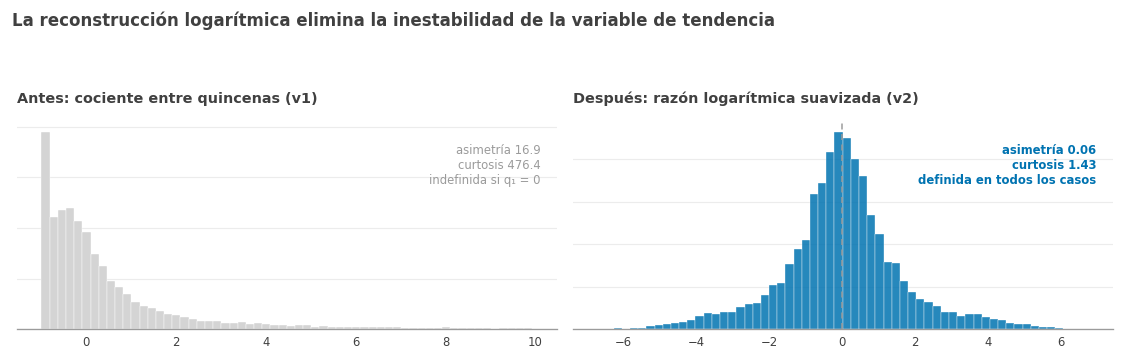

In [9]:
# Figura para el reporte: antes / despues de la reconstruccion
coc = ((q.clics_quincena_2 - q.clics_quincena_1) / q.clics_quincena_1.replace(0, np.nan)).dropna()
lr  = q.log_ratio_actividad

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.0))
a1.hist(coc[coc < 10], bins=60, color=GRIS, edgecolor='white', lw=.25)
a1.text(.97, .90, f'asimetría {st.skew(coc):.1f}\ncurtosis {st.kurtosis(coc):.1f}\nindefinida si q₁ = 0',
        transform=a1.transAxes, ha='right', va='top', fontsize=7, color=GRISOS)
a1.set_title('Antes: cociente entre quincenas (v1)', loc='left', fontsize=8.6, fontweight='bold', pad=12)
limpiar(a1); a1.tick_params(labelsize=7); a1.set_yticklabels([])

a2.hist(lr, bins=60, color=ACENTO, edgecolor='white', lw=.25, alpha=.85)
a2.axvline(0, color=GRISOS, lw=.9, ls=(0, (4, 3)))
a2.text(.97, .90, f'asimetría {st.skew(lr):.2f}\ncurtosis {st.kurtosis(lr):.2f}\ndefinida en todos los casos',
        transform=a2.transAxes, ha='right', va='top', fontsize=7, color=ACENTO, fontweight='bold')
a2.set_title('Después: razón logarítmica suavizada (v2)', loc='left', fontsize=8.6, fontweight='bold', pad=12)
limpiar(a2); a2.tick_params(labelsize=7); a2.set_yticklabels([])

fig.suptitle('La reconstrucción logarítmica elimina la inestabilidad de la variable de tendencia',
             x=.01, ha='left', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, .90]); plt.savefig(FIGS_DIR / 'fig_logratio.pdf'); plt.show()

## Abandono implícito e indicadores de faltante estructural

El abandono implícito (inactividad total sin retiro registrado) se conserva como **indicador
exploratorio complementario**, no como etiqueta alternativa. La segunda etiqueta prevista en
A3.1 del anteproyecto queda, por tanto, fuera del conjunto de trabajo; la decisión debe
documentarse ante la dirección.

In [10]:
con_interaccion = set(map(tuple, studentVle[KEY].drop_duplicates().values))
base['clave'] = list(map(tuple, base[KEY].values))
base['sin_interaccion_vle'] = (~base.clave.isin(con_interaccion)).astype(int)
base['abandono_implicito_total'] = ((base.sin_interaccion_vle == 1) & (base.abandono == 0)).astype(int)
base = base.drop(columns='clave')

print(f'Inscripciones sin interaccion alguna: {base.sin_interaccion_vle.sum():,}')
print(f'   de ellas, con retiro formal      : '
      f'{((base.sin_interaccion_vle == 1) & (base.abandono == 1)).sum():,}')
print(f'   abandono implicito total         : {base.abandono_implicito_total.sum():,}')

Inscripciones sin interaccion alguna: 3,365
   de ellas, con retiro formal      : 2,970
   abandono implicito total         : 395


### Validación del abandono implícito contra `final_result`

Si la población de inactividad total sin retiro formal se concentra en `Fail`, se descarta la
hipótesis de participación por canales no registrados.

                n    pct
final_result            
Fail          373  94.43
Withdrawn      19   4.81
Pass            3   0.76


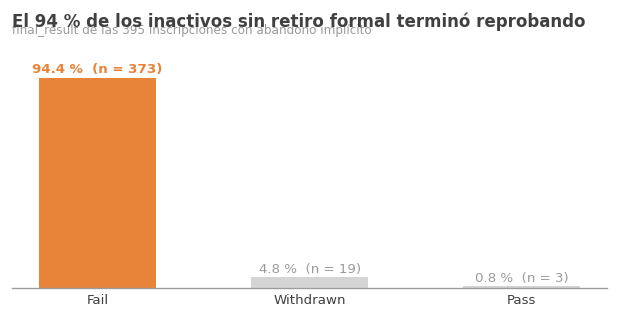

In [11]:
casos = base[base.abandono_implicito_total == 1]
dist = casos.final_result.value_counts()
pct  = (casos.final_result.value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({'n': dist, 'pct': pct}))

orden = [c for c in ['Fail', 'Withdrawn', 'Pass', 'Distinction'] if c in dist.index]
fig, ax = plt.subplots(figsize=(6.4, 2.6))
vals = [pct[c] for c in orden]
cols = [RIESGO if c == 'Fail' else GRIS for c in orden]
ax.bar(range(len(orden)), vals, color=cols, width=.55)
for i, c in enumerate(orden):
    ax.text(i, vals[i] + 2.2, f'{vals[i]:.1f} %  (n = {dist[c]})', ha='center', fontsize=8,
            color=RIESGO if c == 'Fail' else GRISOS, fontweight='bold' if c == 'Fail' else 'normal')
ax.set_xticks(range(len(orden))); ax.set_xticklabels(orden, fontsize=8)
ax.set_ylim(0, 108); ax.set_yticks([]); limpiar(ax, y_grid=False)
ax.set_title('El 94 % de los inactivos sin retiro formal terminó reprobando',
             loc='left', fontsize=10, fontweight='bold', pad=13)
ax.text(0, 1.06, f'final_result de las {len(casos)} inscripciones con abandono implícito',
        transform=ax.transAxes, fontsize=7.2, color=GRISOS)
plt.savefig(FIGS_DIR / 'fig_abandono_implicito.pdf'); plt.show()

## A2.7 — Consolidación del dataset analítico v2

**Corrección 4 (parte 2).** `sin_entregas_tempranas` se construye sobre la ausencia de
**entrega** (`n_evaluaciones_entregadas`), no sobre la ausencia de puntaje. En la versión
anterior se definía sobre `score_promedio_temprano.isna()`, lo que desplazaba el conteo en
los casos con entrega y puntaje nulo cuantificados en A2.5.

**Corrección 6.** La imputación centinela en cero se aplica únicamente a las variables cuyo
cero es semánticamente exacto para una inscripción sin actividad. Donde el cero no es
interpretable, el faltante se preserva: los modelos de *gradient boosting* lo tratan de forma
nativa y la imputación con indicador para la regresión logística se resuelve en el notebook de
modelado, dentro de la validación cruzada. Queda proscrita la imputación por media o mediana,
que destruiría la señal MNAR documentada.

`log_ratio_actividad` se preserva como `NaN` para las inscripciones sin actividad, pese a que
sus quincenas quedan en cero tras la imputación centinela: un cociente de cero sobre cero no
expresa "ausencia de cambio en la tendencia" sino ausencia de tendencia observable.

In [12]:
dataset = (base
    .merge(agg,       on=KEY, how='left')
    .merge(ultima,    on=KEY, how='left')
    .merge(reg,       on=KEY, how='left')
    .merge(sem,       on=KEY, how='left')
    .merge(desempeno, on=KEY, how='left')
    .merge(q,         on=KEY, how='left')
    .merge(pre_curso[KEY + ['interaccion_pre_curso', 'n_interacciones_pre_curso']],
           on=KEY, how='left'))

# Compromiso anticipado: ausencia de registro previo = cero exacto (correccion 9)
dataset['interaccion_pre_curso']     = dataset.interaccion_pre_curso.fillna(0).astype(int)
dataset['n_interacciones_pre_curso'] = dataset.n_interacciones_pre_curso.fillna(0).astype(int)

# Indicadores de faltante estructural — se calculan ANTES de la imputacion centinela
dataset['sin_actividad_ventana_temprana'] = dataset.dias_activos.isna().astype(int)
dataset['sin_entregas_tempranas']         = dataset.n_evaluaciones_entregadas.isna().astype(int)

# Imputacion centinela SOLO donde el cero es semanticamente exacto
CENTINELA_CERO = ['total_clics', 'dias_activos', 'n_interacciones',
                  'clics_quincena_1', 'clics_quincena_2']
for v in CENTINELA_CERO:
    dataset[v] = dataset[v].fillna(0)

# Preservan NaN: score_promedio_temprano, n_evaluaciones_entregadas, coef_variacion_clics,
# log_ratio_actividad, promedio_clics_por_dia_activo, dias_desde_ultima_interaccion, semanas_activas

print(f'Dataset v2: {dataset.shape[0]:,} inscripciones x {dataset.shape[1]} columnas '
      f'(v1: 32 593 x 37)')
print('\nColumnas:'); print(sorted(dataset.columns.tolist()))

Dataset v2: 32,593 inscripciones x 34 columnas (v1: 32 593 x 37)

Columnas:
['abandono', 'abandono_implicito_total', 'age_band', 'clics_quincena_1', 'clics_quincena_2', 'code_module', 'code_presentation', 'coef_variacion_clics', 'date_registration', 'date_unregistration', 'dias_activos', 'dias_desde_ultima_interaccion', 'disability', 'final_result', 'gender', 'highest_education', 'id_student', 'imd_band', 'interaccion_pre_curso', 'log_ratio_actividad', 'momento_retiro', 'n_evaluaciones_entregadas', 'n_interacciones', 'n_interacciones_pre_curso', 'num_of_prev_attempts', 'promedio_clics_por_dia_activo', 'region', 'score_promedio_temprano', 'semanas_activas', 'sin_actividad_ventana_temprana', 'sin_entregas_tempranas', 'sin_interaccion_vle', 'studied_credits', 'total_clics']


## Verificaciones de consolidación

Las aserciones de esta celda son las que la v1 no tenía o tenía neutralizadas. La comprobación
de redundancias exactas es la que habría detectado `semanas_inactivas ≡ 4 − semanas_activas`
antes de exportar el dataset.

In [13]:
# 1. Cardinalidad y llave
assert len(dataset) == 32593, f'Se esperaban 32 593 inscripciones, hay {len(dataset)}'
assert dataset.duplicated(subset=KEY).sum() == 0, 'Llave de inscripcion duplicada'

# 2. Coherencia de los indicadores de faltante estructural (sin neutralizar con 'or True')
assert (dataset.sin_actividad_ventana_temprana == (dataset.dias_activos == 0).astype(int)).all(), \
    'sin_actividad_ventana_temprana incoherente con dias_activos'
assert (dataset.sin_entregas_tempranas ==
        dataset.n_evaluaciones_entregadas.isna().astype(int)).all(), \
    'sin_entregas_tempranas incoherente con n_evaluaciones_entregadas'

# 3. Redundancias suprimidas
for v in ['frecuencia_acceso', 'score_min_temprano', 'semanas_inactivas',
          'variacion_actividad', 'std_clics_diarios', 'media_clics_diarios']:
    assert v not in dataset.columns, f'{v} deberia estar suprimida'

# 4. Rangos admisibles
assert dataset.dias_activos.between(0, VENTANA).all()
assert dataset.dias_desde_ultima_interaccion.dropna().between(0, VENTANA - 1).all()
assert dataset.semanas_activas.dropna().between(1, 4).all()
assert dataset.score_promedio_temprano.dropna().between(0, 100).all()
assert (dataset.total_clics >= 0).all()

# 5. Identidad de la suma de quincenas (dependencia exacta conocida y documentada)
assert np.allclose(dataset.total_clics, dataset.clics_quincena_1 + dataset.clics_quincena_2), \
    'total_clics != q1 + q2'
print('total_clics = clics_quincena_1 + clics_quincena_2 (dependencia exacta conocida:')
print('  en modelos lineales se retienen las quincenas y no el total).')

# 6. Busqueda de redundancias exactas NO documentadas
num = dataset.select_dtypes(include=[np.number]).drop(columns=['id_student'])
corr = num.corr(method='spearman')
pares = [(corr.index[i], corr.columns[j], corr.iloc[i, j])
         for i in range(len(corr)) for j in range(i + 1, len(corr))
         if abs(corr.iloc[i, j]) > 0.999]
if pares:
    print('\nREDUNDANCIAS EXACTAS DETECTADAS (|rho| > 0,999):')
    for a, b, r in pares: print(f'  {a} ~ {b}: rho = {r:.4f}')
    raise AssertionError('Resolver las redundancias antes de exportar el dataset')
print('\nSin pares con |rho| > 0,999 fuera de la identidad de quincenas.')
print('Verificaciones de consolidacion: OK')

total_clics = clics_quincena_1 + clics_quincena_2 (dependencia exacta conocida:
  en modelos lineales se retienen las quincenas y no el total).

Sin pares con |rho| > 0,999 fuera de la identidad de quincenas.
Verificaciones de consolidacion: OK


In [14]:
salida = PROCESSED_DIR / 'dataset_analitico_oulad_v2.parquet'
for v in CENTINELA_CERO:
    dataset[v] = dataset[v].astype('int32')
dataset['momento_retiro'] = dataset.momento_retiro.astype('category')
dataset.to_parquet(salida, index=False)
print(f'Guardado: {salida.name}  ({dataset.shape[0]:,} x {dataset.shape[1]})')

resumen = pd.DataFrame({
    'no_nulos': dataset.notna().sum(),
    'nulos':    dataset.isna().sum(),
    'pct_nulos': (dataset.isna().mean() * 100).round(2),
    'dtype':    dataset.dtypes.astype(str),
})
print('\nEstructura del dataset analitico v2:')
print(resumen.to_string())

Guardado: dataset_analitico_oulad_v2.parquet  (32,593 x 34)

Estructura del dataset analitico v2:
                                no_nulos  nulos  pct_nulos     dtype
code_module                        32593      0       0.00    object
code_presentation                  32593      0       0.00    object
id_student                         32593      0       0.00     int64
date_registration                  32548     45       0.14   float64
date_unregistration                10072  22521      69.10   float64
gender                             32593      0       0.00    object
region                             32593      0       0.00    object
highest_education                  32593      0       0.00    object
imd_band                           31482   1111       3.41    object
age_band                           32593      0       0.00    object
num_of_prev_attempts               32593      0       0.00     int64
studied_credits                    32593      0       0.00     int64
disab

## Estado y siguiente paso

**Producto:** `dataset_analitico_oulad_v2.parquet` — versión definitiva del Resultado esperado 1
del anteproyecto y punto de partida del Objetivo específico 3.

**Pendiente antes de modelar**

1. **Verificación del v2** en `03b_verificacion_v2.ipynb`: asimetría y curtosis de
   `log_ratio_actividad`, ausencia de pares con |ρ| = 1 y VIF sin valores no definidos.
   El informe estadístico `03_analisis_estadistico.ipynb` **no debe re-ejecutarse** sobre el
   v2: es el diagnóstico del v1 y es lo que justifica estas correcciones.
2. **Reevaluar `coef_variacion_clics`** con la construcción corregida antes de decidir su
   exclusión.
3. **Definir el evento a predecir** con la dirección, entre las tres rutas cuyas prevalencias
   calcula la celda de `momento_retiro`. Ninguna conclusión de modelado es definitiva mientras
   esa decisión no se cierre.
4. **Ratificar el uso de una única ventana** de 28 días, o implementar varias longitudes según
   compromete la actividad A2.2 del anteproyecto.